## 01 - Analyse exploratoire et prétraitement (California Housing)
##

In [2]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

 ## 2.2 Présentation du jeu de données

In [3]:
df = pd.read_csv("../data/raw/housing.csv")
print("Shape:", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())
print("\nAperçu :")
display(df.head())

Shape: (20640, 10)

Colonnes disponibles :
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Aperçu :


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2.3 Analyse exploratoire (EDA)


In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print("Statistiques descriptives – variables numériques brutes :")
display(desc)

Statistiques descriptives – variables numériques brutes :


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100,-0.297801,-1.330152
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500,0.465953,-1.117760
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000,0.060331,-0.800629
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000,4.147343,32.630927
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000,3.459546,21.985575
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000,4.935858,73.553116
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000,3.410438,22.057988
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001,1.646657,4.952524
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000,0.977763,0.327870


 # Visualisations


### Histogrammes

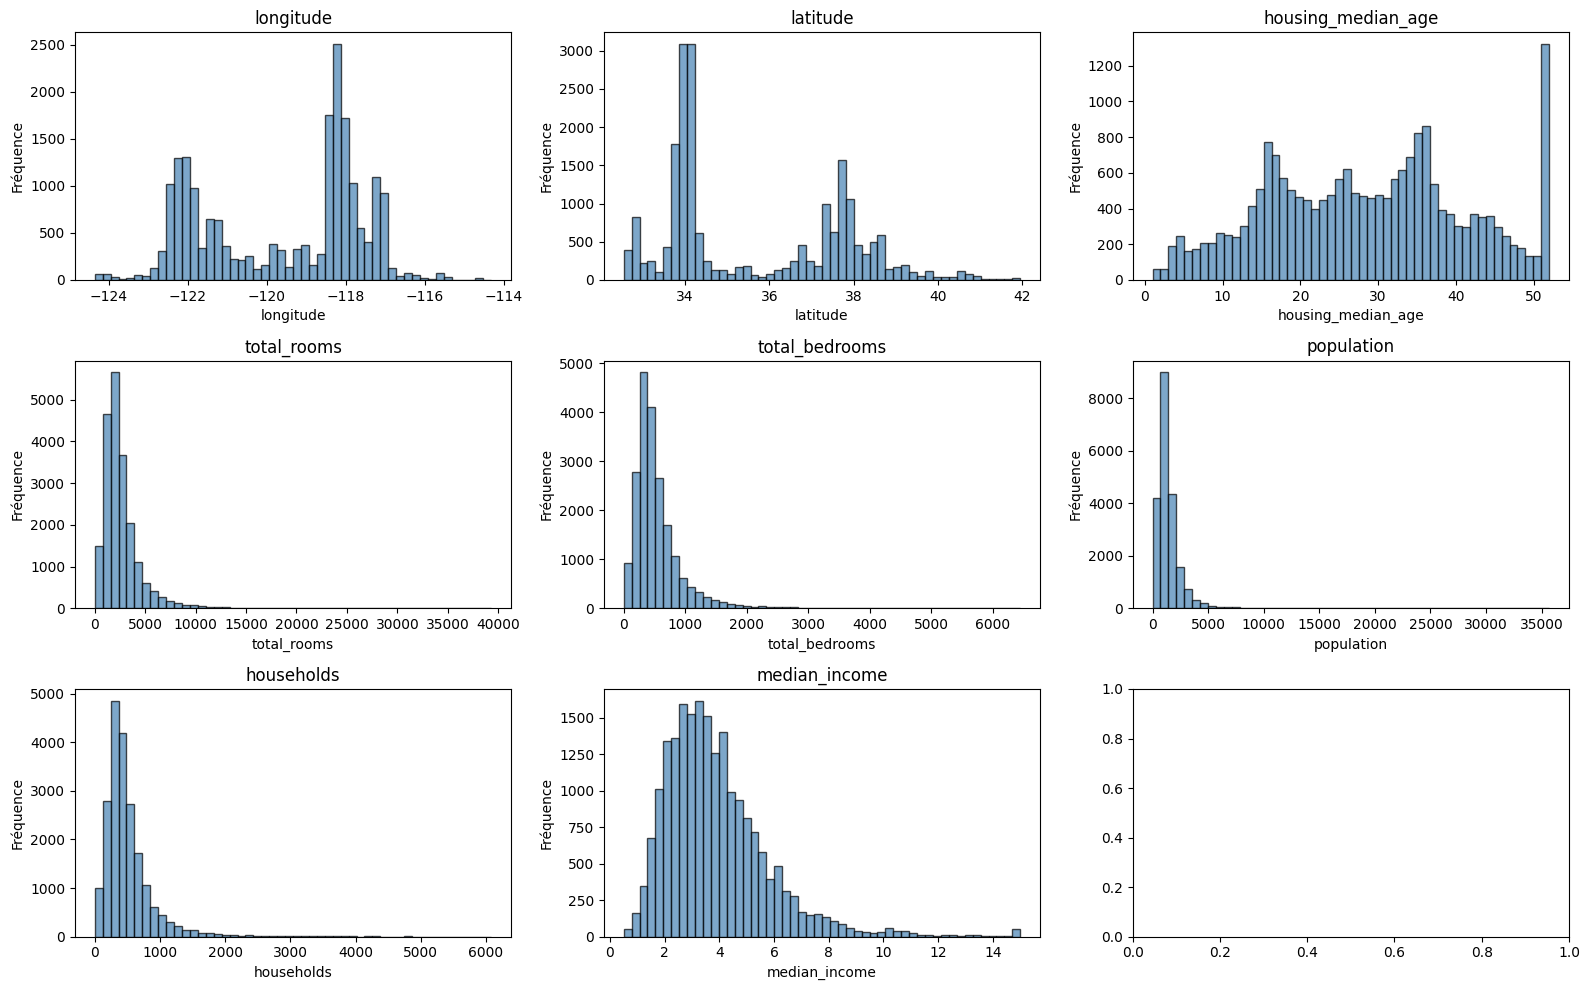

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for i, col in enumerate(numeric_cols[:-1]):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig("../figures/hist_features.png", dpi=150)
plt.show()


### Boxplots

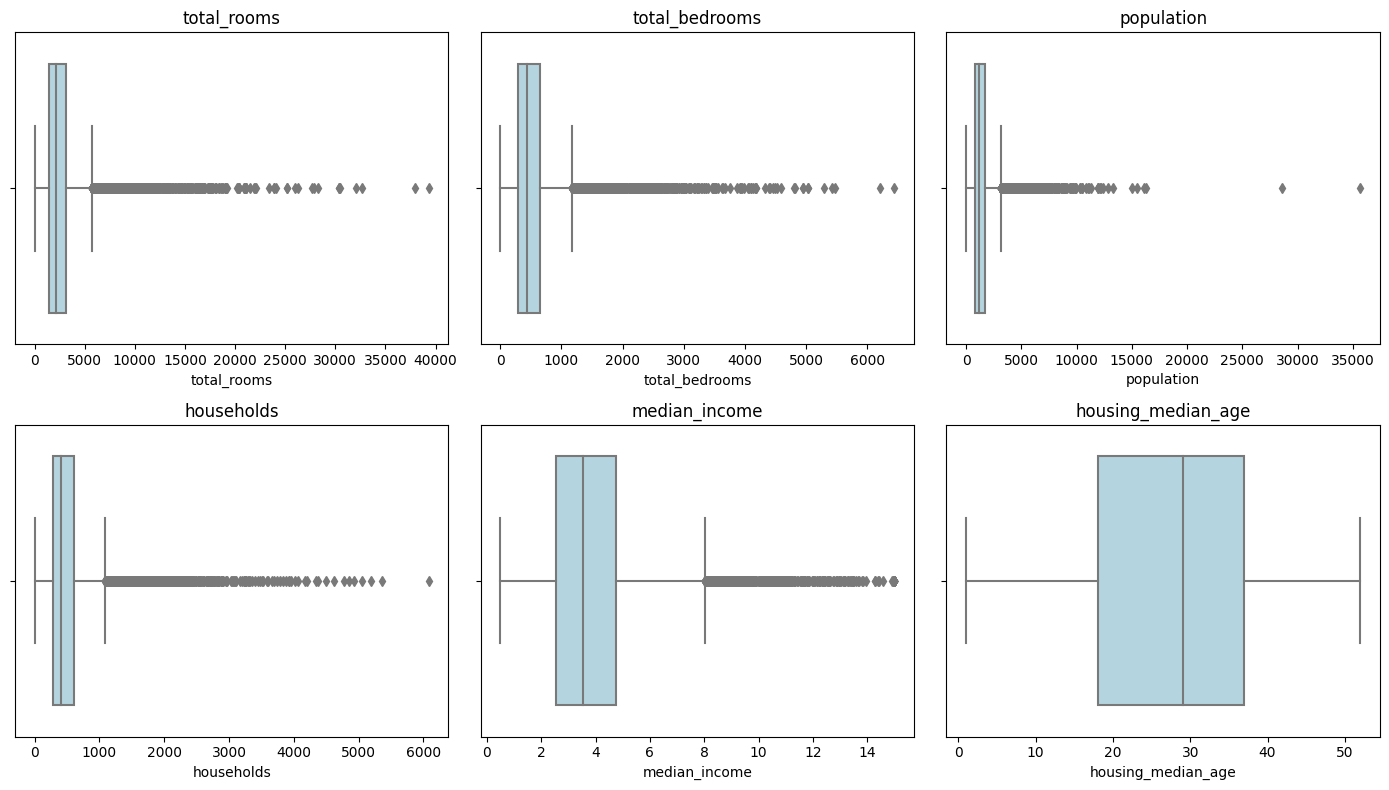

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(['total_rooms', 'total_bedrooms', 'population', 
                         'households', 'median_income', 'housing_median_age']):
    ax = axes[i//3, i%3]
    sns.boxplot(x=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../figures/boxplots_outliers.png", dpi=150)
plt.show()

# Scatter

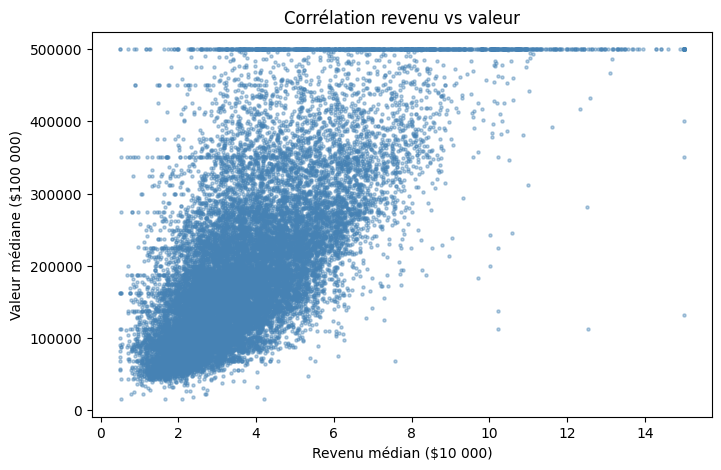

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.4, s=5, c='steelblue')
plt.xlabel('Revenu médian ($10 000)')
plt.ylabel('Valeur médiane ($100 000)')
plt.title('Corrélation revenu vs valeur')
plt.savefig("../figures/scatter_income_value.png", dpi=150)
plt.show()

### Carte géographique

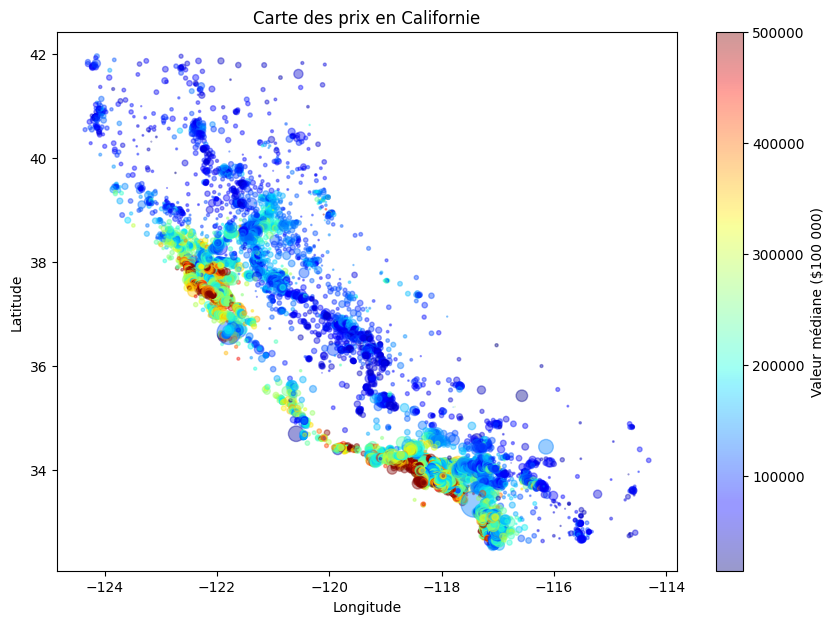

In [9]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], 
                 c=df['median_house_value'], 
                 s=df['population']/100, 
                 alpha=0.4, cmap='jet')
plt.colorbar(sc, label='Valeur médiane ($100 000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Carte des prix en Californie')
plt.savefig("../figures/geo_price_map.png", dpi=150)
plt.show()


# Matrice de corrélation et VIF (avant transformation)

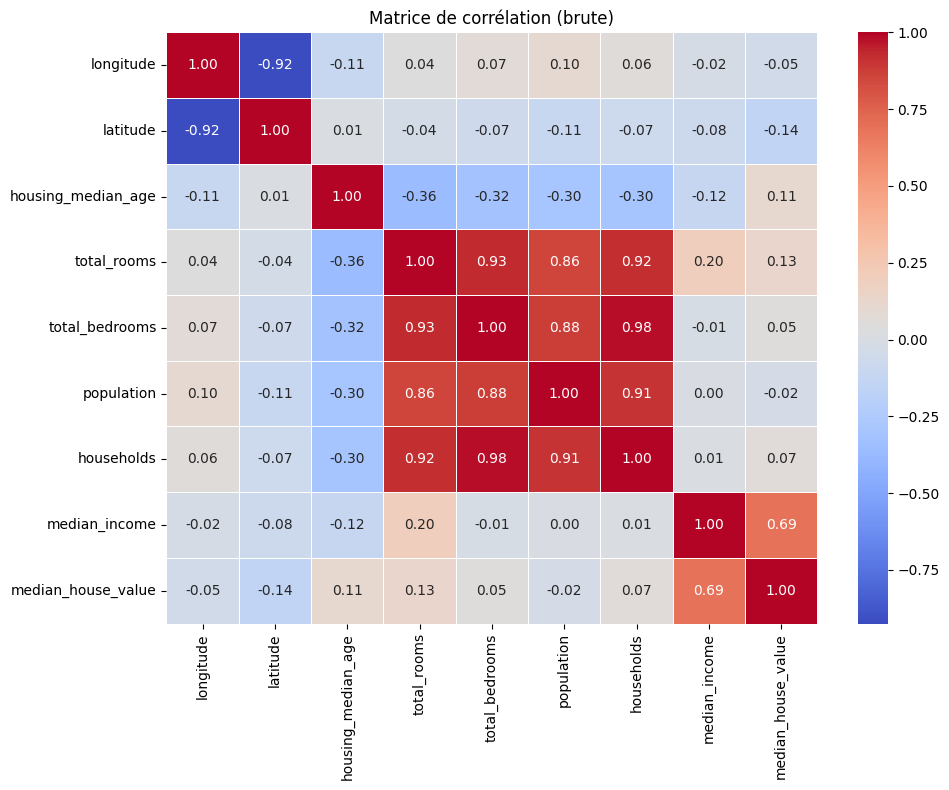

VIF initial (seuil critique > 10) :
              feature         VIF
0           longitude  615.913539
1            latitude  549.460506
2  housing_median_age    7.280281
3         total_rooms   30.511021
4      total_bedrooms   93.969627
5          population   16.431328
6          households   91.444123
7       median_income    8.258816


In [10]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation (brute)')
plt.tight_layout()
plt.savefig("../figures/correlation_matrix_raw.png", dpi=150)
plt.show()

X_vif = df[numeric_cols].drop('median_house_value', axis=1).dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("VIF initial (seuil critique > 10) :")
print(vif_data)

# Création de ratios pour réduire la multicolinéarité

In [11]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df = df.drop(columns=['total_rooms', 'total_bedrooms', 'population', 'households'])
print("Shape après ajout des ratios :", df.shape)

Shape après ajout des ratios : (20640, 9)


# Vérification VIF après ratios

In [12]:
numeric_cols_new = df.select_dtypes(include=[np.number]).columns.tolist()
X_vif_new = df[numeric_cols_new].drop('median_house_value', axis=1).dropna()
vif_data_new = pd.DataFrame()
vif_data_new['feature'] = X_vif_new.columns
vif_data_new['VIF'] = [variance_inflation_factor(X_vif_new.values, i) for i in range(X_vif_new.shape[1])]
print("VIF après création des ratios :")
print(vif_data_new)


VIF après création des ratios :
                    feature         VIF
0                 longitude  745.975037
1                  latitude  571.513770
2        housing_median_age    6.435988
3             median_income    9.203734
4       rooms_per_household    7.151737
5         bedrooms_per_room   26.949351
6  population_per_household    1.087705


# Détection des valeurs manquantes

Valeurs manquantes :
longitude                     0
latitude                      0
housing_median_age            0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64


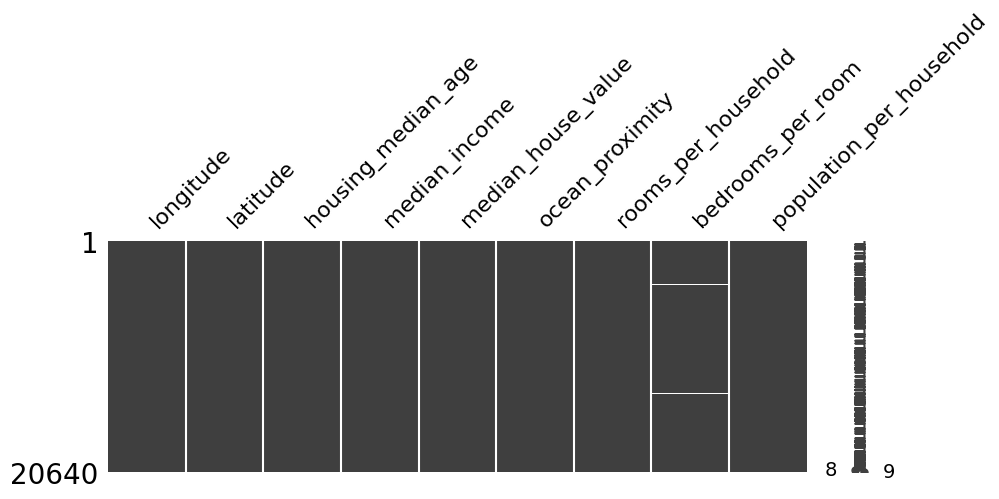

In [13]:
print("Valeurs manquantes :")
print(df.isnull().sum())
msno.matrix(df, figsize=(10, 3))
plt.savefig("../figures/missingno_matrix.png", dpi=150)
plt.show()

## 2.4 Prétraitement

### 2.4.1 Encodage one-hot

In [14]:
print("Modalités de ocean_proximity :")
print(df['ocean_proximity'].value_counts())
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded = df_encoded.astype(float)
print("Shape après encodage :", df_encoded.shape)

Modalités de ocean_proximity :
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
Shape après encodage : (20640, 12)


### 2.4.2 Partitionnement train/test

In [15]:
target_col = 'median_house_value'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

TEST_SIZE = 0.2
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (16512, 11), Test : (4128, 11)


 ### 2.4.3 Imputation des valeurs manquantes (après split)



In [16]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()
X_train_imputed[['bedrooms_per_room']] = imputer.fit_transform(X_train[['bedrooms_per_room']])
X_test_imputed[['bedrooms_per_room']] = imputer.transform(X_test[['bedrooms_per_room']])

print("Valeurs manquantes après imputation :")
print(pd.concat([X_train_imputed.isnull().sum().rename('train'),
                 X_test_imputed.isnull().sum().rename('test')], axis=1))

Valeurs manquantes après imputation :
                            train  test
longitude                       0     0
latitude                        0     0
housing_median_age              0     0
median_income                   0     0
rooms_per_household             0     0
bedrooms_per_room               0     0
population_per_household        0     0
ocean_proximity_INLAND          0     0
ocean_proximity_ISLAND          0     0
ocean_proximity_NEAR BAY        0     0
ocean_proximity_NEAR OCEAN      0     0


### 2.4.4 Transformation logarithmique (pour réduire l'asymétrie)

In [17]:
skewed_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
for col in skewed_features:
    X_train_imputed[col] = np.log1p(X_train_imputed[col])
    X_test_imputed[col] = np.log1p(X_test_imputed[col])

print("Transformation log1p appliquée sur les variables présentant une forte asymétrie.")

Transformation log1p appliquée sur les variables présentant une forte asymétrie.


### 2.4.5 Standardisation (centrage-réduction)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_imputed.columns, index=X_test_imputed.index)

print("Standardisation appliquée (moyenne=0, variance=1).")

Standardisation appliquée (moyenne=0, variance=1).


### 2.4.6 Sauvegarde des données finales

In [19]:
X_train_scaled.to_csv("../data/processedd/X_train.csv", index=False)
X_test_scaled.to_csv("../data/processedd/X_test.csv", index=False)
y_train.to_csv("../data/processedd/y_train.csv", index=False)
y_test.to_csv("../data/processedd/y_test.csv", index=False)
print("Données sauvegardées dans data/processed/")

Données sauvegardées dans data/processed/


## 2.5 Synthèse

In [20]:
print("""
Résumé des opérations effectuées :
---------------------------------
1. Chargement : 20 640 obs., 9 variables explicatives (dont 1 catégorielle).
2. Détection des valeurs manquantes : 207 sur total_bedrooms (0,99%) – imputation médiane.
3. Analyse d'asymétrie : skewness > 1 sur certaines variables → transformation log1p.
4. Détection des outliers : conservation (données réelles).
5. Multicolinéarité (VIF > 100) → création de ratios (rooms_per_household, bedrooms_per_room, population_per_household).
6. Encodage one-hot de ocean_proximity (5 → 4 variables).
7. Partitionnement : 80% train / 20% test, random_state=42.
8. Imputation après split (fit sur train, transform sur test).
9. Transformation logarithmique sur les variables asymétriques.
10. Standardisation (StandardScaler).
11. Sauvegarde des données prétraitées.
""")


Résumé des opérations effectuées :
---------------------------------
1. Chargement : 20 640 obs., 9 variables explicatives (dont 1 catégorielle).
2. Détection des valeurs manquantes : 207 sur total_bedrooms (0,99%) – imputation médiane.
3. Analyse d'asymétrie : skewness > 1 sur certaines variables → transformation log1p.
4. Détection des outliers : conservation (données réelles).
5. Multicolinéarité (VIF > 100) → création de ratios (rooms_per_household, bedrooms_per_room, population_per_household).
6. Encodage one-hot de ocean_proximity (5 → 4 variables).
7. Partitionnement : 80% train / 20% test, random_state=42.
8. Imputation après split (fit sur train, transform sur test).
9. Transformation logarithmique sur les variables asymétriques.
10. Standardisation (StandardScaler).
11. Sauvegarde des données prétraitées.



# Explications

---

## 1. Coefficient d’asymétrie (skewness)

Le coefficient d’asymétrie est défini par :

$
\text{Skewness} =
\frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^3}
{\left(\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2\right)^{3/2}}
$

- Si $\text{Skewness} > 0$ : asymétrie à droite  
- Si $\text{Skewness} < 0$ : asymétrie à gauche  
- Si $|\text{Skewness}| > 1$ : forte asymétrie  

---

## 2. Transformation logarithmique

$
x' = \ln(x + 1)
$

Cette transformation réduit l’asymétrie et stabilise la variance.

---

## 3. Création de ratios

$
\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}
$

$
\text{bedrooms\_per\_room} = \frac{\text{total\_bedrooms}}{\text{total\_rooms}}
$

$
\text{population\_per\_household} = \frac{\text{population}}{\text{households}}
$

---

## 4. Variance Inflation Factor (VIF)

$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$

avec $R_j^2$ le coefficient de détermination de la régression de $X_j$ sur les autres variables.

- $VIF > 5$ ou $10$ → multicolinéarité forte

---

## 5. Imputation par la médiane

$
\tilde{y} = \text{median}(y_1, y_2, \dots, y_n)
$

---

## 6. Standardisation

$
Z = \frac{X - \mu}{\sigma}
$

avec :

$
\mu = \frac{1}{n}\sum_{i=1}^{n} X_i
$

$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(X_i - \mu)^2}
$

---

## 7. Encodage one-hot

$
I_m(x) =
\begin{cases}
1 & \text{si } x = m \\
0 & \text{sinon}
\end{cases}
$

---

## 8. Partitionnement train / test

$
\mathcal{D}_{train} \cap \mathcal{D}_{test} = \emptyset
$

$
\mathcal{D}_{train} \cup \mathcal{D}_{test} = \mathcal{D}
$

Split typique : 80% / 20%

---

##  Conclusion

Ces transformations permettent :
- robustesse statistique  
- réduction de la multicolinéarité  
- meilleure généralisation  
- stabilité des modèles  